In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
import os
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.pipeline import Pipeline
from matplotlib.patches import Patch
from sklearn.metrics import silhouette_samples
import matplotlib.cm as cm

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

In [81]:
RANDOM_STATE = 0
TRAIN_PATH = "train_data.csv"
TOP_K_FEATURES = 40  # Reducing to 40 features for better clustering
N_CLUSTERS = 6 # Optimal K found during experimentation - explained after clluster creation

In [82]:
df = pd.read_csv(TRAIN_PATH)

print(f"Class distribution:\n{df['Bankrupt?'].value_counts()}")

Class distribution:
Bankrupt?
0    5609
1     198
Name: count, dtype: int64


### Section 3.1 - Feature Selection

In [83]:
y = df["Bankrupt?"]
X = df.drop(columns=["Index", "Bankrupt?"])

# Step 1: Variance Threshold (remove constant features)
selector = VarianceThreshold(threshold=0)
X_var = selector.fit_transform(X)
selected_cols = X.columns[selector.get_support()]
X_var_df = pd.DataFrame(X_var, columns=selected_cols)

print(f"Features after variance threshold: {X_var_df.shape[1]}")

# Step 2: Random Forest for Feature Importance
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight="balanced"
)
rf.fit(X_var_df, y)

# Get top K features
importances = pd.Series(rf.feature_importances_, index=X_var_df.columns)
top_features = importances.sort_values(ascending=False).head(TOP_K_FEATURES).index.tolist()

print(f"DEBUG: Top {TOP_K_FEATURES} features selected: {top_features[:5]}...")

# Save selected features list
joblib.dump(top_features, "top_features_for_clustering.joblib")

Features after variance threshold: 94
DEBUG: Top 40 features selected: [' Total debt/Total net worth', ' Persistent EPS in the Last Four Seasons', ' Borrowing dependency', ' Debt ratio %', ' Net Income to Total Assets']...


['top_features_for_clustering.joblib']

#### Saved top_features_for_clustering.joblib

In [84]:
# Create pipeline only for the selected features
X_reduced = X_var_df[top_features].copy()

scaler = StandardScaler()
scaler.fit(X_reduced)

# Save the scaler package
preprocess_package = {
    "feature_names": top_features,
    "scaler": scaler
}
joblib.dump(preprocess_package, "preprocess_for_clustering.joblib")
print("Saved preprocess_for_clustering.joblib")

# Transform data for clustering
X_scaled = scaler.transform(X_reduced)

Saved preprocess_for_clustering.joblib


### Section 3.2 - Clustering


DEBUG: Running Elbow Method...
  K=4: Inertia=174991.14, Silhouette=0.1841
  K=5: Inertia=164555.94, Silhouette=0.2353
  K=6: Inertia=157183.47, Silhouette=0.1410
  K=7: Inertia=150561.08, Silhouette=0.1444


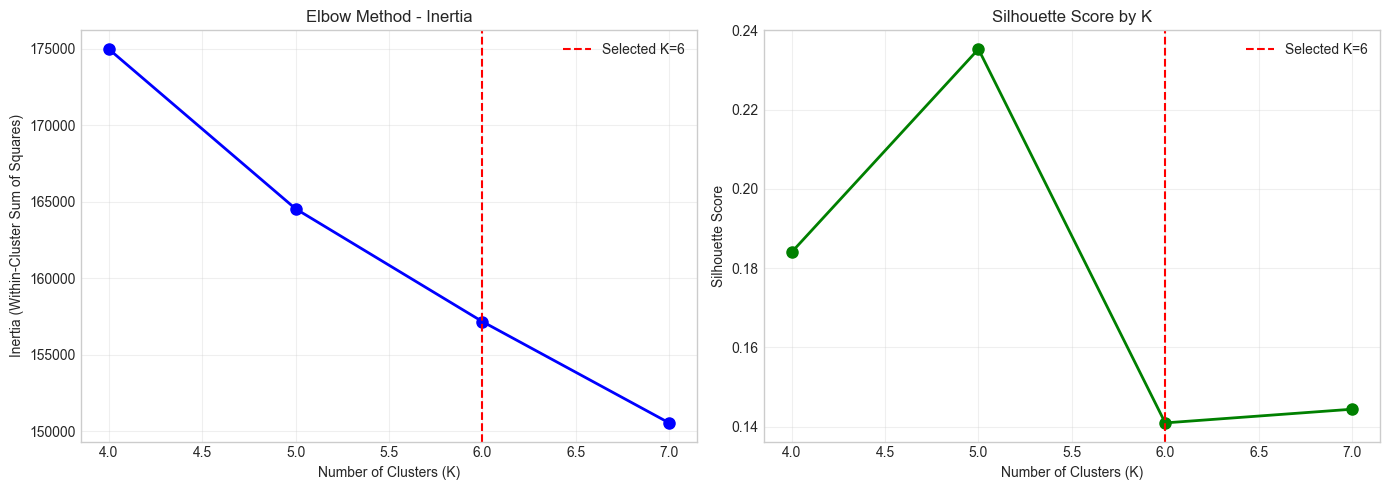

In [85]:
# Elbow Method to determine optimal K
inertias = []
silhouette_scores = []
K_range = range(4, 8)

print("\nDEBUG: Running Elbow Method...")
for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    kmeans_temp.fit(X_scaled)
    inertias.append(kmeans_temp.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans_temp.labels_))
    print(f"  K={k}: Inertia={kmeans_temp.inertia_:.2f}, Silhouette={silhouette_scores[-1]:.4f}")

# Plot both metrics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Elbow curve (Inertia)
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].axvline(x=N_CLUSTERS, color='red', linestyle='--', label=f'Selected K={N_CLUSTERS}')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)')
axes[0].set_title('Elbow Method - Inertia')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: Silhouette scores
axes[1].plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[1].axvline(x=N_CLUSTERS, color='red', linestyle='--', label=f'Selected K={N_CLUSTERS}')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score by K')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [86]:
print(f"K={N_CLUSTERS}")

kmeans = KMeans(
    n_clusters=N_CLUSTERS,
    init="k-means++",
    n_init=20,
    random_state=RANDOM_STATE
)
cluster_labels = kmeans.fit_predict(X_scaled)

# Add cluster labels to original dataframe
df["cluster"] = cluster_labels

# Save KMeans model
joblib.dump(kmeans, "kmeans_clusters.joblib")
print("Saved kmeans_clusters.joblib")

# Evaluate Clustering
sil_score = silhouette_score(X_scaled, cluster_labels)
print(f"Silhouette Score: {sil_score:.4f}")

K=6
Saved kmeans_clusters.joblib
Silhouette Score: 0.1410


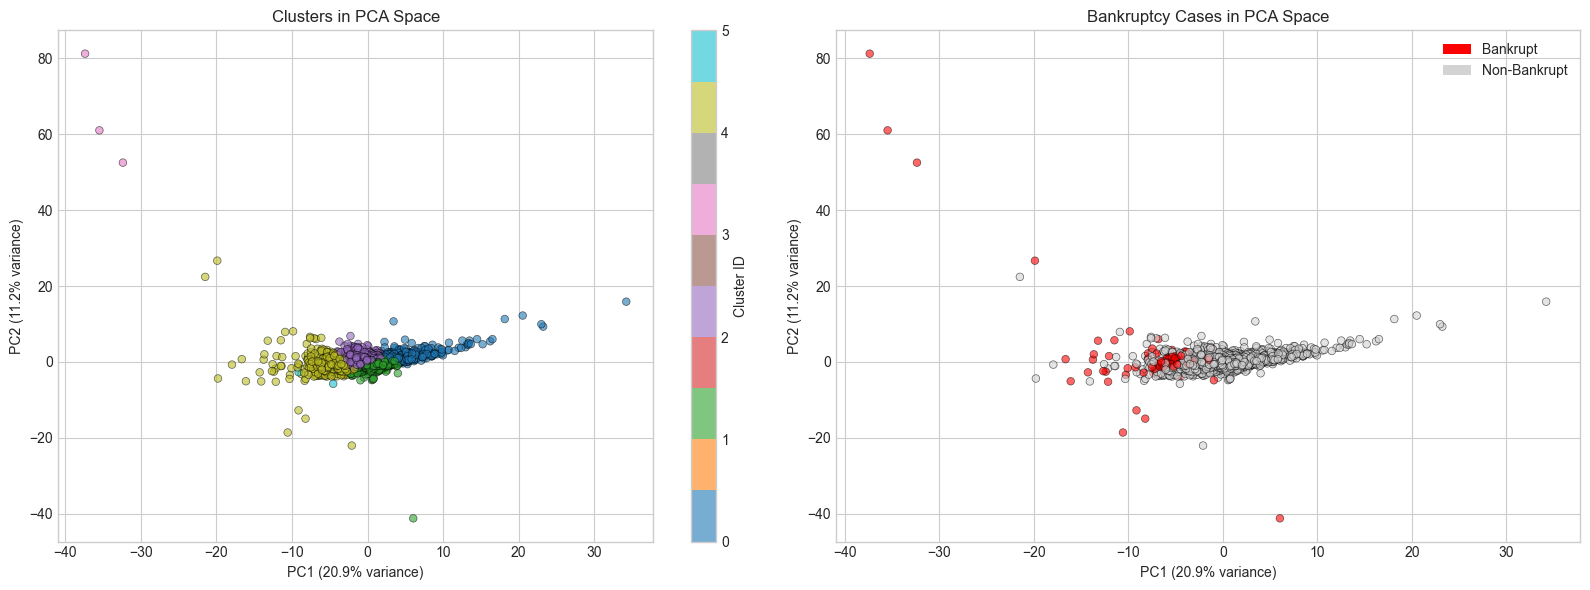

In [87]:
# PCA for visualization
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

# Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Color by cluster
scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], 
                           c=cluster_labels, 
                           cmap='tab10', 
                           alpha=0.6, 
                           s=30, 
                           edgecolors='k', 
                           linewidth=0.5)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
axes[0].set_title('Clusters in PCA Space')
plt.colorbar(scatter1, ax=axes[0], label='Cluster ID')

# Right: Color by bankruptcy status
colors = ['lightgray' if b == 0 else 'red' for b in y]
scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], 
                           c=colors, 
                           alpha=0.6, 
                           s=30, 
                           edgecolors='k', 
                           linewidth=0.5)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
axes[1].set_title('Bankruptcy Cases in PCA Space')

# Add legend for bankruptcy
legend_elements = [Patch(facecolor='red', label='Bankrupt'),
                   Patch(facecolor='lightgray', label='Non-Bankrupt')]
axes[1].legend(handles=legend_elements, loc='best')

plt.tight_layout()
plt.savefig("pca_cluster_visualization.png", dpi=300)
plt.show()

In [88]:
# Cluster Analysis Report
cluster_stats = []

for c in range(N_CLUSTERS):
    sub = df[df["cluster"] == c]
    n_total = len(sub)
    n_bankrupt = sub["Bankrupt?"].sum()
    pct_bankrupt = (n_bankrupt / n_total) * 100 if n_total > 0 else 0
    
    # Compliance
    if n_bankrupt > 0:
        action = "Stacking Model will be used"
    else:
        action = "Constant 0 Allowed"
        
    print(f"Cluster {c}: {n_total:4d} companies | {n_bankrupt:3d} bankrupt ({pct_bankrupt:.2f}%) -> {action}")
    
    cluster_stats.append({
        "Cluster": c,
        "Total": n_total,
        "Bankrupt": n_bankrupt,
        "Action": action
    })

Cluster 0:  545 companies |   0 bankrupt (0.00%) -> Constant 0 Allowed
Cluster 1: 1979 companies |   5 bankrupt (0.25%) -> Stacking Model will be used
Cluster 2: 2620 companies |  75 bankrupt (2.86%) -> Stacking Model will be used
Cluster 3:    3 companies |   3 bankrupt (100.00%) -> Stacking Model will be used
Cluster 4:  658 companies | 115 bankrupt (17.48%) -> Stacking Model will be used
Cluster 5:    2 companies |   0 bankrupt (0.00%) -> Constant 0 Allowed


### We evaluated K=5, 6, and 7 using the elbow method. While K=5 achieved the highest silhouette score (0.147), it produced only 3 clusters requiring stacking models, insufficient for our 4-member team. K=7 generated 5 clusters needing models, creating uneven workload and two extremely challenging clusters with ≤3 bankruptcies. K=6 (silhouette: 0.141) provided the optimal balance: exactly 4 clusters requiring models with a more favorable distribution of bankruptcies (115, 75, 5, 3), meeting project requirements while maintaining comparable clustering quality. The 4% reduction in silhouette score was an acceptable trade-off for practical team alignment.

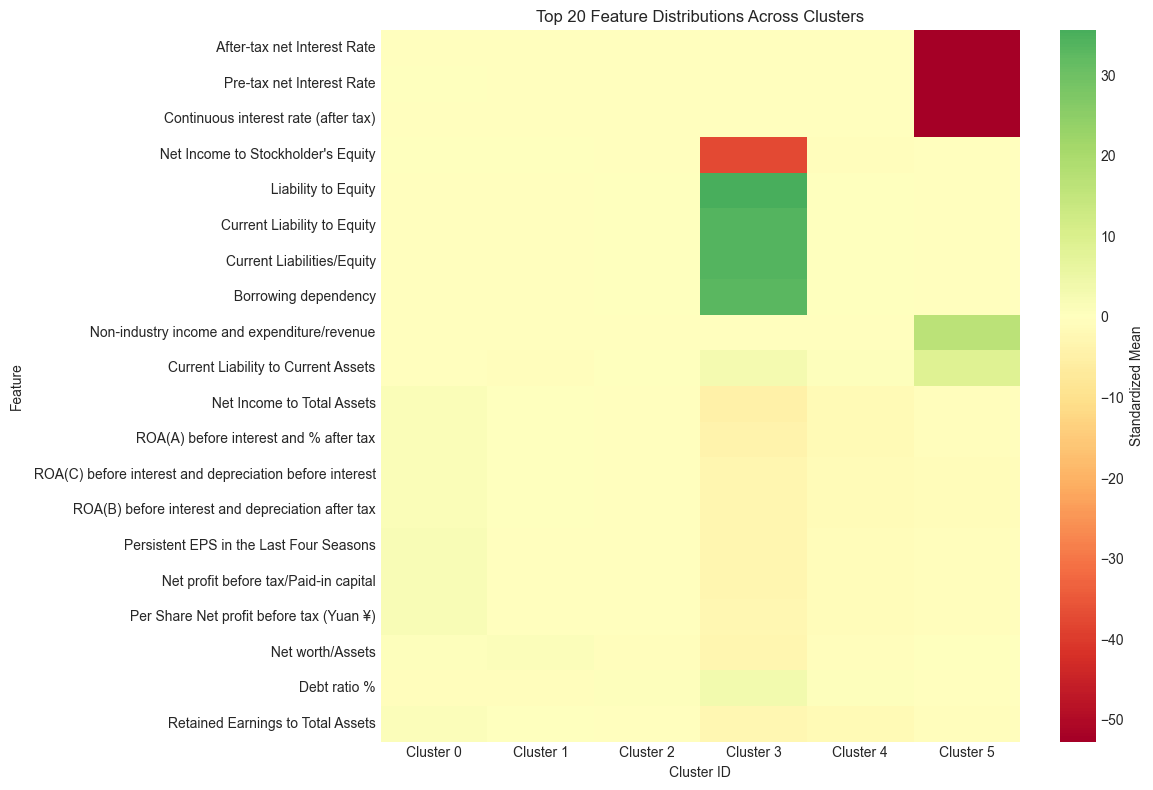

In [89]:
# Feature distributions across clusters (standardized means)
cluster_feature_means = []
for c in range(N_CLUSTERS):
    cluster_mask = cluster_labels == c
    cluster_mean = X_scaled[cluster_mask].mean(axis=0)
    cluster_feature_means.append(cluster_mean)

cluster_means_df = pd.DataFrame(cluster_feature_means, 
                                 index=[f'Cluster {i}' for i in range(N_CLUSTERS)],
                                 columns=top_features)

# Select top 20 most varying features across clusters
feature_variance = cluster_means_df.var(axis=0).sort_values(ascending=False)
top_varying = feature_variance.head(20).index

plt.figure(figsize=(12, 8))
sns.heatmap(cluster_means_df[top_varying].T, 
            annot=False, 
            cmap='RdYlGn', 
            center=0,
            cbar_kws={'label': 'Standardized Mean'})
plt.title('Top 20 Feature Distributions Across Clusters')
plt.xlabel('Cluster ID')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig("cluster_feature_heatmap.png", dpi=300)
plt.show()

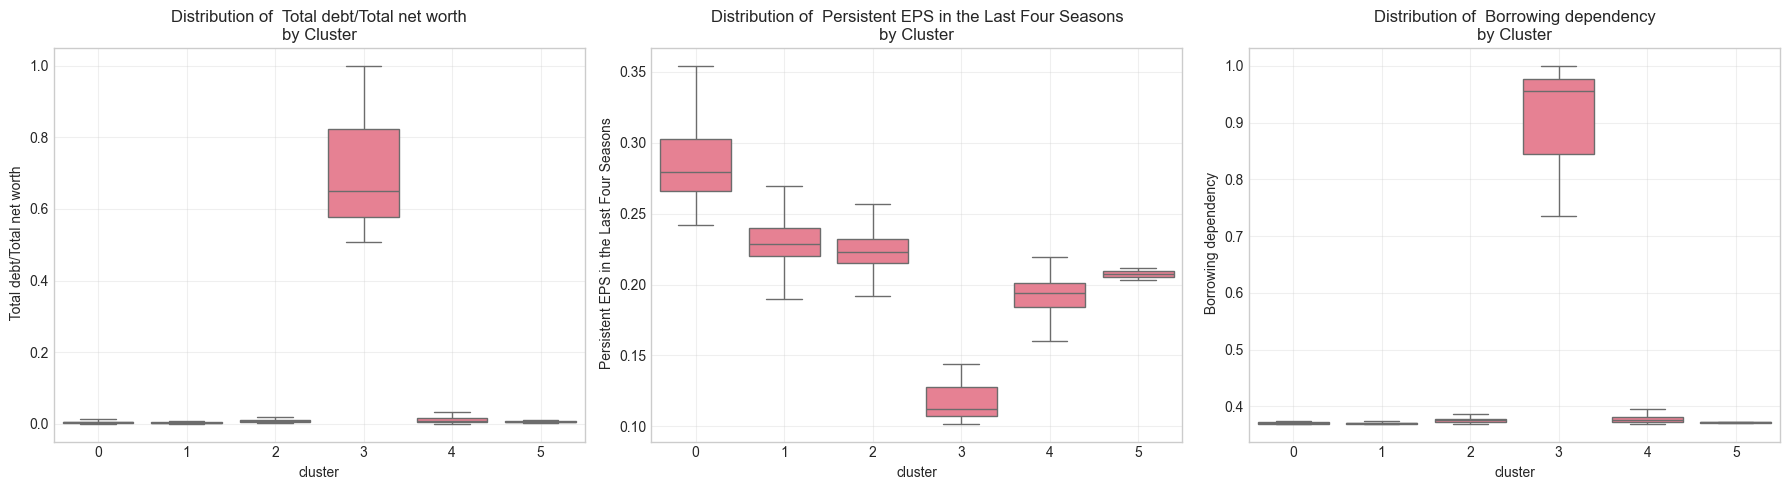

In [90]:
# We will visualize the distribution of the top 3 most important features across clusters
# This explains "Why" the clusters are different.

top_3_features = top_features[:3]

plt.figure(figsize=(18, 5))
for i, feature in enumerate(top_3_features):
    plt.subplot(1, 3, i+1)
    sns.boxplot(x="cluster", y=feature, data=df, showfliers=False) # Hide outliers for cleaner view
    plt.title(f"Distribution of {feature}\nby Cluster")
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("cluster_characteristics.png") # Save for report
plt.show()

In [91]:
# Save the full training set with clusters
df.to_csv("train_with_clusters.csv", index=False)

# Save individual cluster files for team members
print("Saving individual cluster files...")
for c in range(N_CLUSTERS):
    sub = df[df["cluster"] == c]
    filename = f"cluster_{c}.csv"
    sub.to_csv(filename, index=False)
    print(f"{filename} ({len(sub)} rows)")

Saving individual cluster files...
cluster_0.csv (545 rows)
cluster_1.csv (1979 rows)
cluster_2.csv (2620 rows)
cluster_3.csv (3 rows)
cluster_4.csv (658 rows)
cluster_5.csv (2 rows)


## Section 3.3.1

In [92]:
df_all = pd.read_csv("train_with_clusters.csv")
print(f"Loaded train_with_clusters.csv (Shape: {df_all.shape})")

Loaded train_with_clusters.csv (Shape: (5807, 98))


In [93]:
preprocess_obj = joblib.load("preprocess_for_clustering.joblib")
scaler = preprocess_obj["scaler"]
feature_names = preprocess_obj["feature_names"]

print(f"Loaded preprocessing: Scaler + {len(feature_names)} features.")

Loaded preprocessing: Scaler + 40 features.


In [94]:
# Selecting features used for clustering
X_raw = df_all[feature_names]
y_cluster = df_all["cluster"]

# Apply the same scaling
X_cluster_train = scaler.transform(X_raw)

print(f"Training Cluster Classifier on {X_cluster_train.shape[0]} rows.")

Training Cluster Classifier on 5807 rows.


In [95]:
# Random Forest to learn the boundaries between clusters.
clf_cluster = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

clf_cluster.fit(X_cluster_train, y_cluster)

RandomForestClassifier(max_depth=15, n_estimators=200, n_jobs=-1,
                       random_state=0)

In [96]:
# Evaluation
y_pred_cluster = clf_cluster.predict(X_cluster_train)
acc = accuracy_score(y_cluster, y_pred_cluster)

print(f"Overall Train Accuracy: {acc:.4f}")
print("\nClassification Report (Per-Cluster Performance):")
print(classification_report(y_cluster, y_pred_cluster, zero_division=0))

Overall Train Accuracy: 0.9998

Classification Report (Per-Cluster Performance):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       545
           1       1.00      1.00      1.00      1979
           2       1.00      1.00      1.00      2620
           3       1.00      1.00      1.00         3
           4       1.00      1.00      1.00       658
           5       1.00      1.00      1.00         2

    accuracy                           1.00      5807
   macro avg       1.00      1.00      1.00      5807
weighted avg       1.00      1.00      1.00      5807



In [97]:
importances = clf_cluster.feature_importances_
indices = np.argsort(importances)[::-1]

print("\nTop 5 Features for Distinguishing Clusters:")
for i in range(5):
    print(f"{i+1}. {feature_names[indices[i]]} (Imp: {importances[indices[i]]:.4f})")

# Save the cluster ID prediction model
cluster_id_package = {
    "model": clf_cluster,
    "features": feature_names,
    "scaler": scaler 
}

# Saving as 'cluster_id_predictor.joblib' to avoid confusion
joblib.dump(cluster_id_package, "cluster_id_predictor.joblib")


Top 5 Features for Distinguishing Clusters:
1.  Equity to Liability (Imp: 0.0818)
2.  Liability to Equity (Imp: 0.0795)
3.  Per Share Net profit before tax (Yuan ¥) (Imp: 0.0645)
4.  Persistent EPS in the Last Four Seasons (Imp: 0.0644)
5.  Debt ratio % (Imp: 0.0618)


['cluster_id_predictor.joblib']

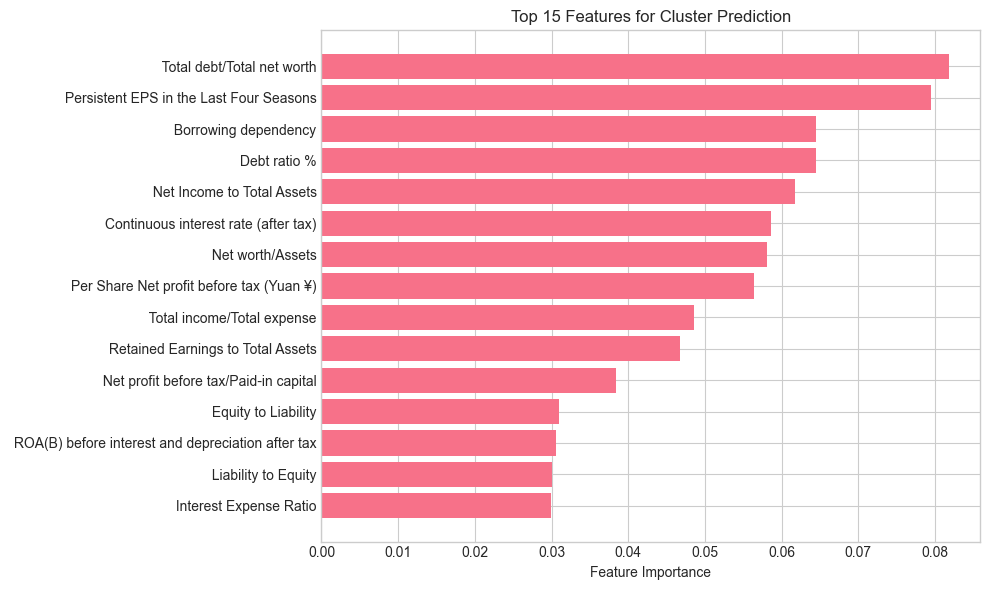

In [98]:
# Feature Importance Visualization
top_n = 15
feat_imp_df = pd.DataFrame({
    'feature': feature_names[:top_n],
    'importance': clf_cluster.feature_importances_[indices[:top_n]]
})

plt.figure(figsize=(10, 6))
plt.barh(range(top_n), feat_imp_df['importance'][::-1], align='center')
plt.yticks(range(top_n), feat_imp_df['feature'][::-1])
plt.xlabel('Feature Importance')
plt.title('Top 15 Features for Cluster Prediction')
plt.tight_layout()
plt.savefig("cluster_predictor_importance.png")
plt.show()